# The financing chapter — what the swap-financed pair actually costs

For most of this project the carry was one number with a range around it: 250 / 600 / 1200
basis points a year, for "the four hatched components combined". That was honest and it was
useless to negotiate with. A desk cannot quote against a bracket that does not say what is
inside it.

This notebook opens it. Two of the four components turn out to be measurable from series
already landed, one is a desk quote and stays bracketed, and one **cannot be measured at all**
with the data on hand and is drawn hatched at zero rather than assumed away.

In [1]:
%matplotlib inline
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from pipeline.viz import theme, figures
from pipeline.package import financing as F
theme.apply()
legs, summary = F.rate_legs(), F.carry_summary()
components, fed = F.carry_components(), F.fed_sensitivity()

## 1. The structure

The product is not "financing". It is a cross-currency structure with four legs, and the
question a client asks is which of them they face. They face one.

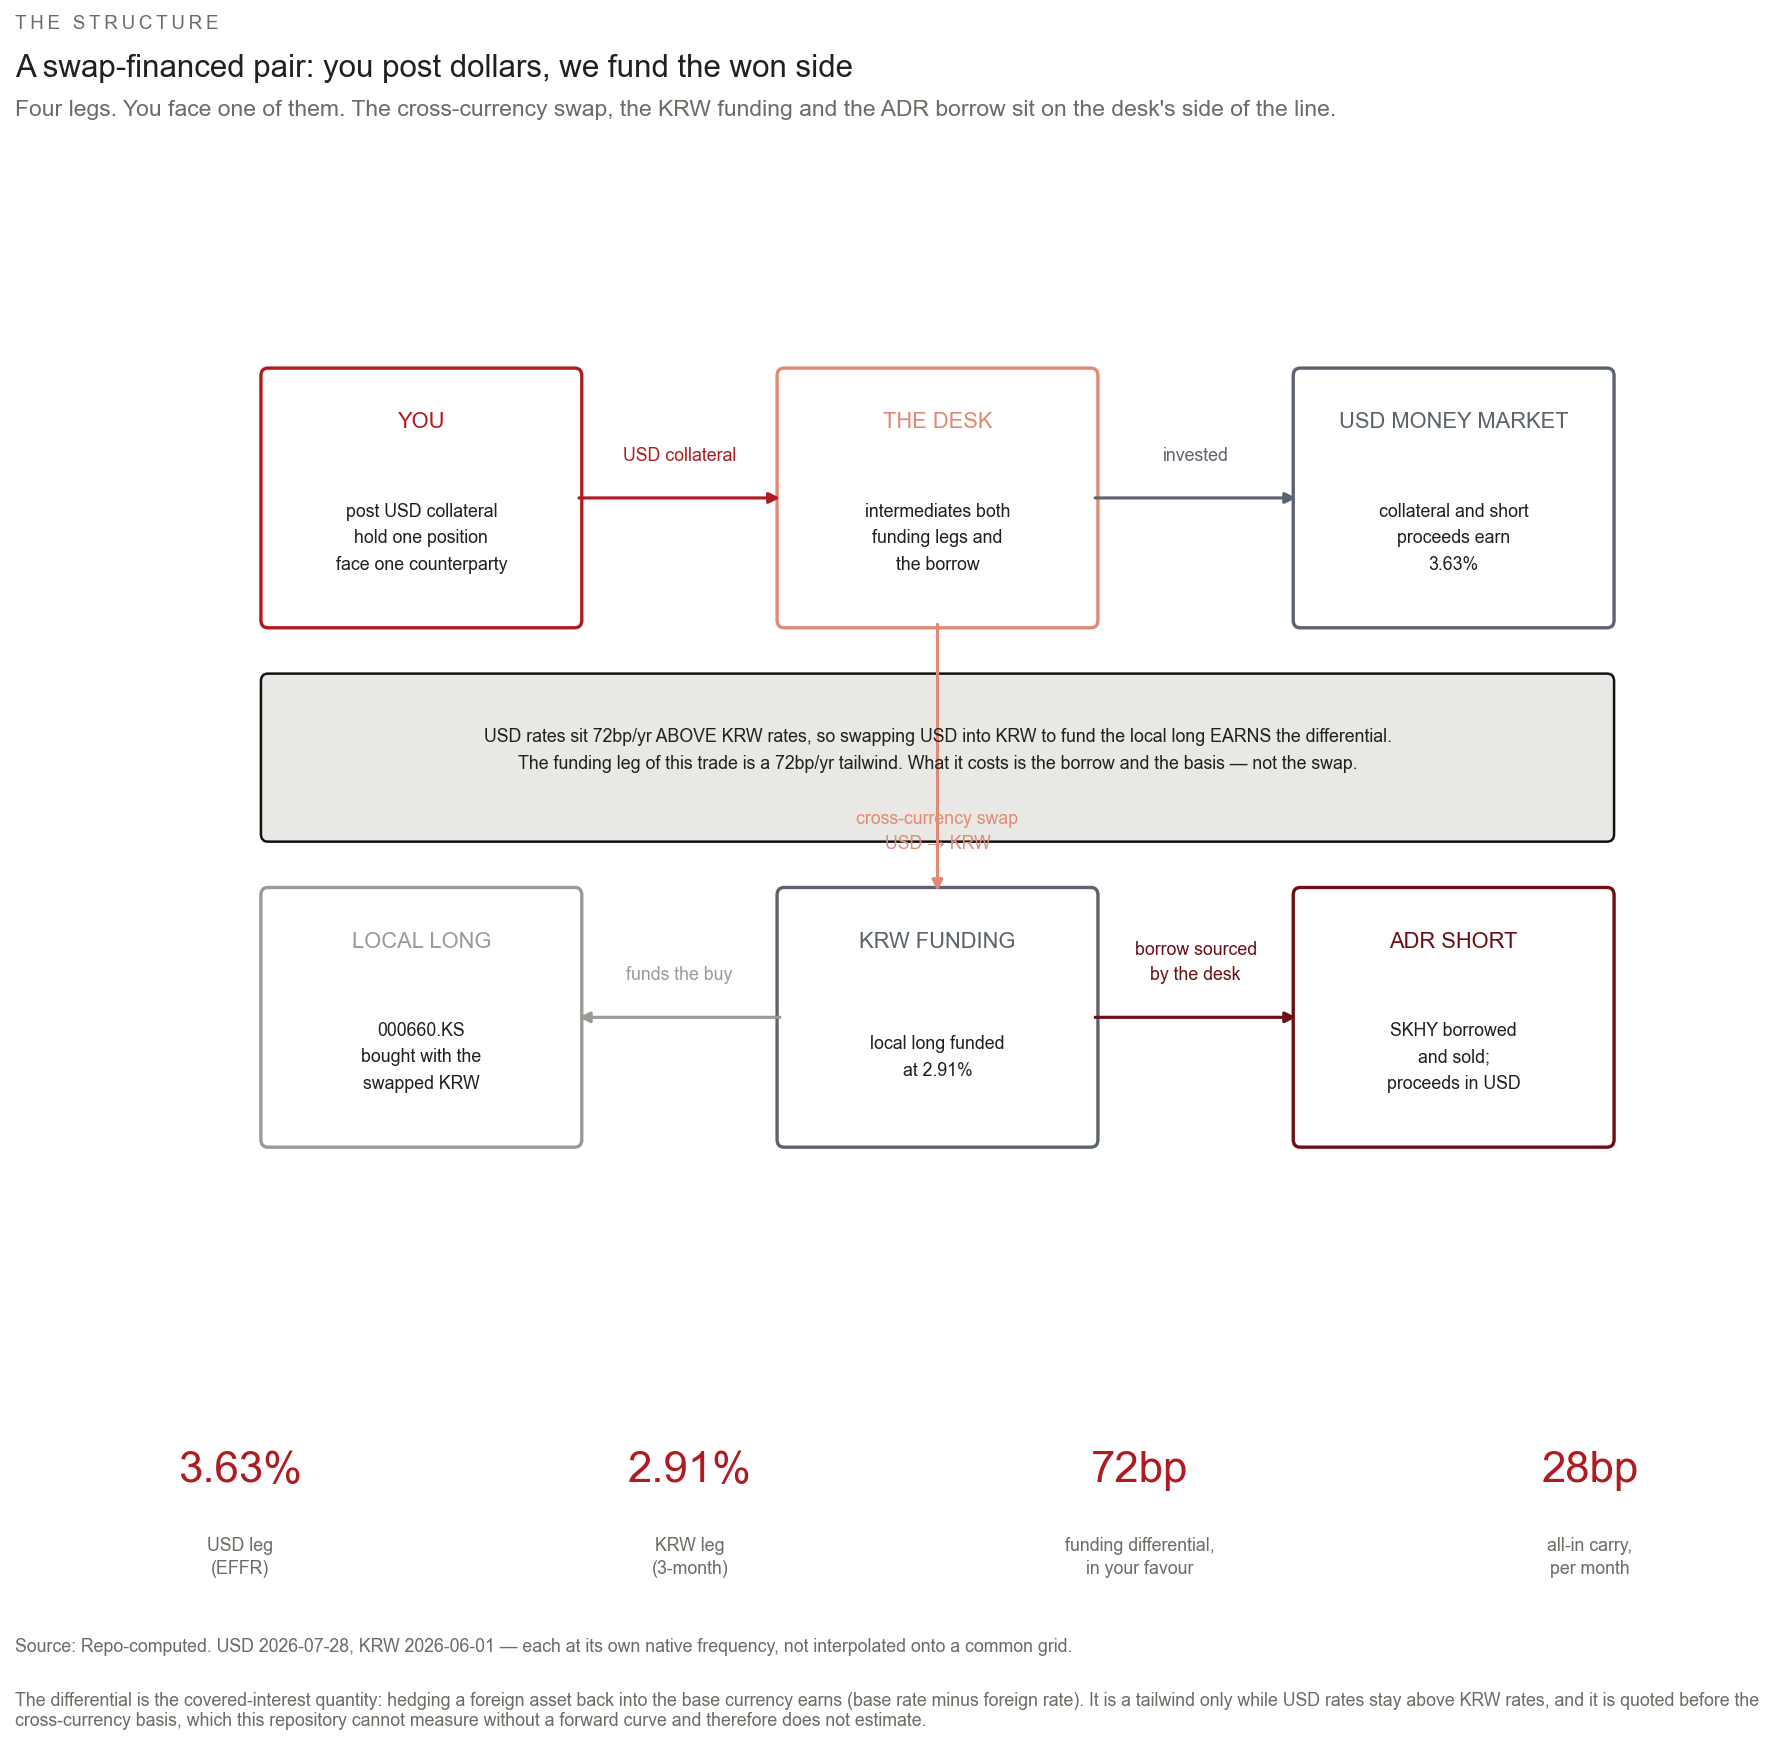

In [2]:
fig, _ = figures.g29a_financing_structure(legs, summary)
fig;

### The sign that matters, and it is counter-intuitive

USD rates sit **above** KRW rates. The position is long the KRW asset, funded from USD. Under
covered interest parity, hedging a foreign asset back into the base currency earns
`base rate − foreign rate` — so the funding differential on this trade is a **tailwind, not a
cost**.

That inverts the reflex. "Financing cost" implies the swap is what you pay for. At today's
rates the swap pays *you*, and what you actually pay for is the borrow.

In [3]:
pd.DataFrame([{"leg": legs["usd_series"], "level_pct": legs["usd_rate_pct"], "as_of": legs["usd_as_of"]},
              {"leg": legs["krw_series"], "level_pct": legs["krw_rate_pct"], "as_of": legs["krw_as_of"]},
              {"leg": "differential (USD − KRW)", "level_pct": legs["differential_bp"]/100, "as_of": "—"}])

,leg,level_pct,as_of
0,"EFFR, daily",3.63,2026-07-28
1,"Korea 3-month rate, monthly",2.91,2026-06-01
2,differential (USD − KRW),0.72,—


Each leg is read at **its own** last observation. The Korea rate is published monthly and the
US rate daily; resampling the monthly series onto a daily grid to make them share a timestamp
would manufacture observations nobody published, and a level comparison does not need them to.

## 2. The carry, by component

Three different kinds of bar, because a chart that renders a measurement and an assumption
identically is worse than the single bracket it replaces.

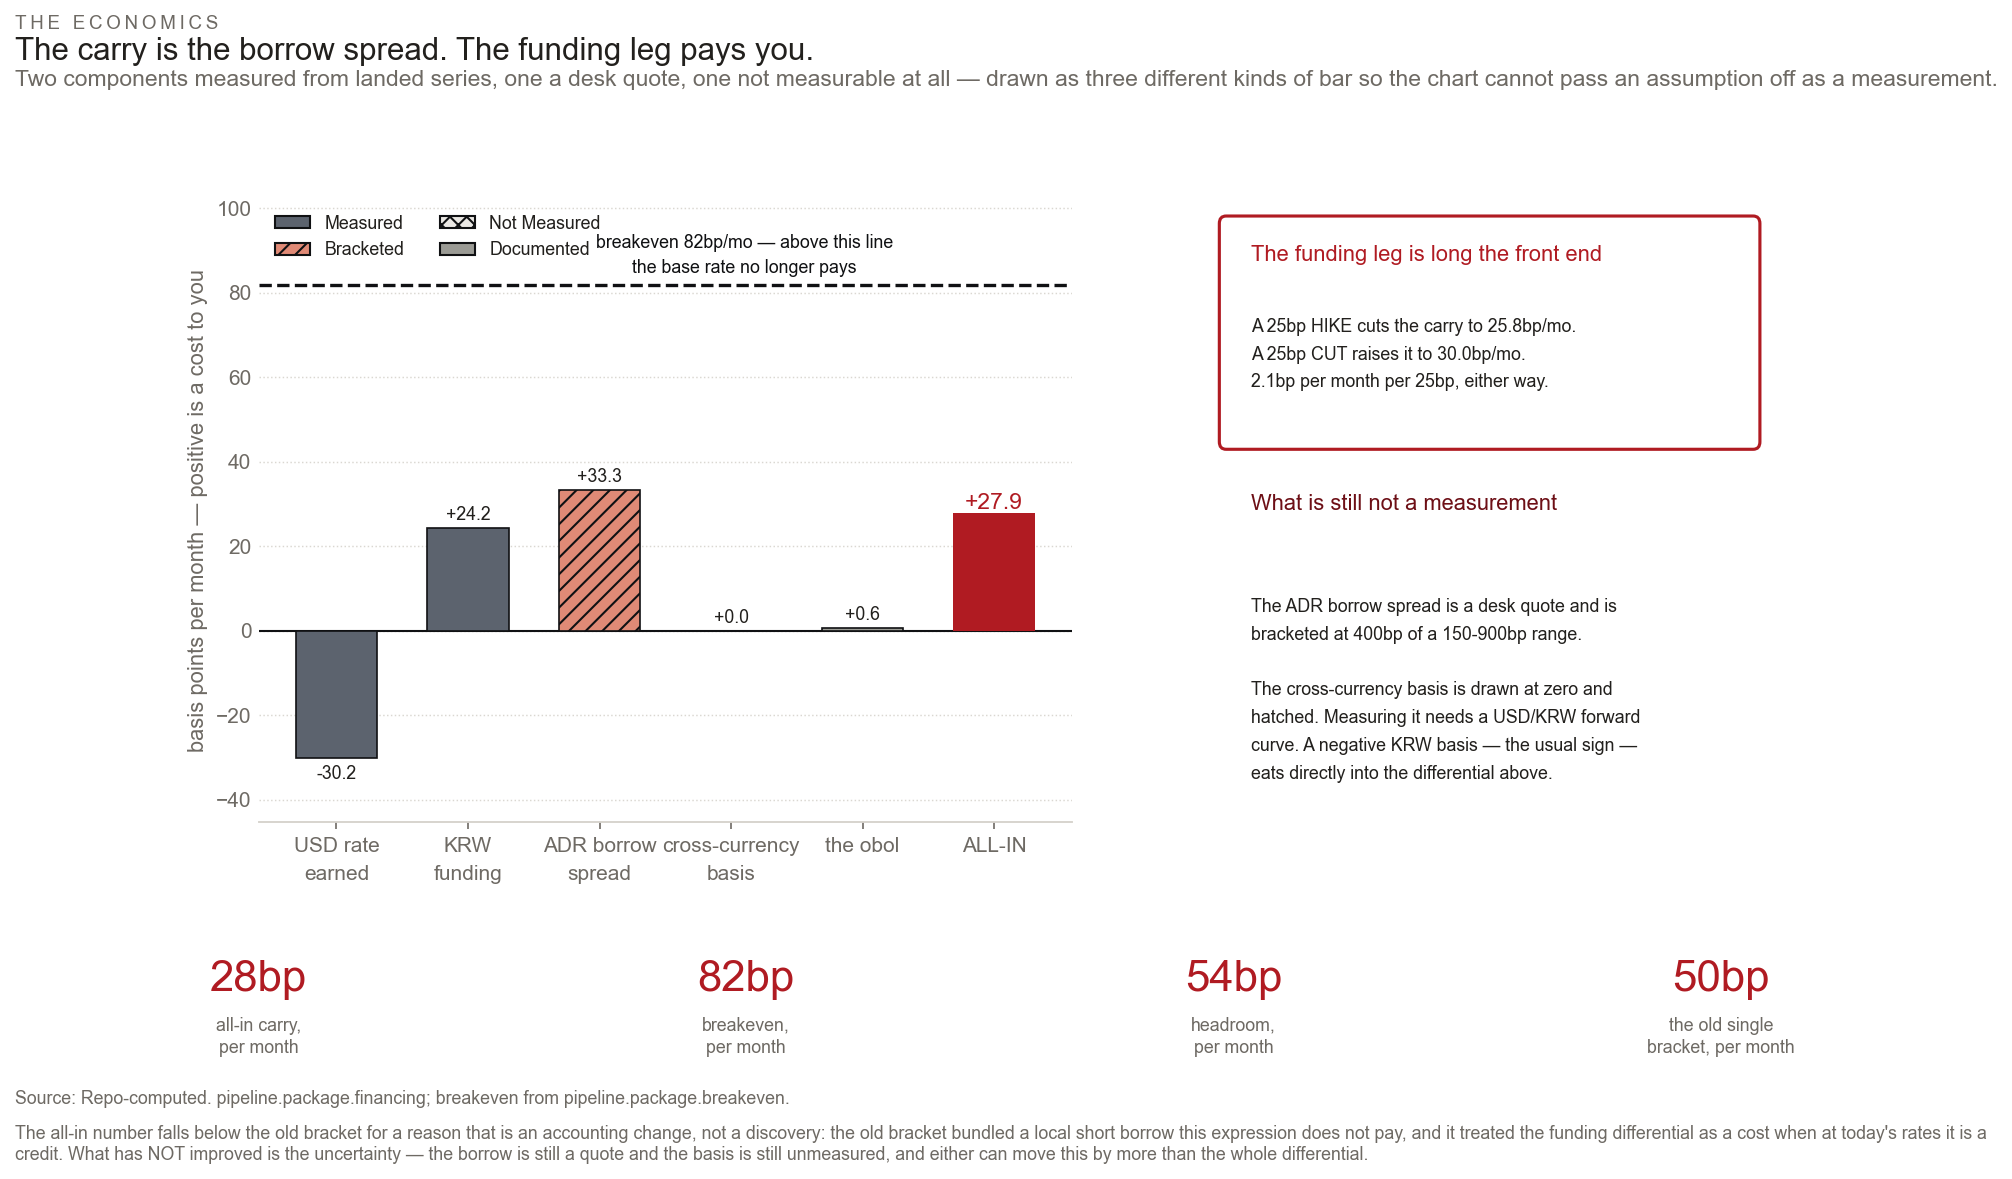

In [4]:
fig, _ = figures.g29b_carry_decomposition(components, summary, fed)
fig;

In [5]:
components[["component", "status", "bp_per_year", "bp_per_month", "source"]]

,component,status,bp_per_year,bp_per_month,source
0,USD rate earned on collateral and short proceeds,MEASURED,-363.0,-30.250000,"EFFR, daily, 2026-07-28"
1,KRW funding on the local long,MEASURED,291.0,24.250000,"Korea 3-month rate, monthly, 2026-06-01"
2,ADR borrow spread,BRACKETED,400.0,33.333333,desk quote pending; mid of 150-900bp
3,cross-currency basis,NOT MEASURED,0.0,0.000000,not measured — needs a USD/KRW forward curve; ...
4,"the obol (conversion, amortised)",DOCUMENTED,7.0,0.583333,7.0bp round trip over 252 sessions


**Read the total carefully.** It comes in below the old bracket, and the reason is an
accounting change rather than a discovery. The old bracket bundled a *local short borrow* that
this expression does not pay — the local leg is long — and it treated the funding differential
as a cost when at today's rates it is a credit.

What has **not** improved is the uncertainty. The borrow spread is still a quote, the basis is
still unmeasured, and either can move the total by more than the entire differential.

## 3. Fed sensitivity

The USD rate enters with a negative sign: it is *earned* on collateral and short proceeds, not
paid. So a hike makes this trade **cheaper** to hold and a cut makes it dearer — the opposite
of the reflex for a levered position.

In [6]:
pd.Series(fed)

shift_bp                                                                     25.0
carry_now_bp_per_year                                                       335.0
carry_after_hike_bp_per_year                                                310.0
carry_after_cut_bp_per_year                                                 360.0
bp_per_month_per_25bp                                                        2.08
direction                       A HIKE REDUCES the cost of holding this trade ...
caveat                          Assumes the KRW leg and the borrow spread are ...
dtype: object

The sentence for the slide: *the funding leg of this trade is long the front end, and it moves
about 2 basis points a month per 25 basis points of Fed.*

**The FOMC calendar is not landed.** Marking meeting dates on the carry chart needs the dates
themselves, and this repository does not hold a sourced calendar series. They are public and
routine to add — but adding them from memory is exactly the kind of shortcut that puts a wrong
date on a client chart, so the calendar is named as unlanded rather than typed in.

## 4. The probe: can the cross-currency basis be measured?

The basis is the wedge between the forward points and the rate differential. Measuring it needs
a USD/KRW forward curve.

- **SGX USD/KRW forwards** are not landed. There is no registry entry and no raw file. The
  deferral is already recorded in `docs/features_m6.md`: deferred months are `exchange_marked`
  rather than executable, so a curve built from them would be part quote and part mark, and no
  traded-cost claim may rest on it.
- **FRED** carries neither a KRW cross-currency basis nor a KRW forward curve.
- What remains are commercial curve providers, which is a subscription decision and not a
  session task.

So the honest quantity available today is the **rate differential**, and the basis is reported
as a named gap with its sign risk stated: a negative KRW basis — the usual sign for an Asian
funding currency — makes swapping into KRW more expensive than parity and eats directly into
the tailwind above.

---
**Informational only.** Not advice, not a recommendation, not a solicitation. The borrow spread
is a bracketed assumption pending a desk quote; the cross-currency basis is unmeasured. Real
financing levels are the desk's to quote.